In [1]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

In [2]:
path = '../data/raw/'
print(os.listdir(path))

['test', 'train', 'val', '__MACOSX']


In [3]:
def walk_directory(start_path):
    for root, dirs, files in os.walk(start_path):
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
        if '_MACOSX' in root:
            continue
        if len(image_files) > 0:
            print(f"{os.path.relpath(root, start_path)}: {len(image_files)} images")

walk_directory(path)

test\NORMAL: 234 images
test\PNEUMONIA: 390 images
train\NORMAL: 1341 images
train\PNEUMONIA: 3875 images
val\NORMAL: 8 images
val\PNEUMONIA: 8 images


In [4]:
def image_percentage(start_path):
    total_files = 0
    print(f"Calculating percentage of images in each directory in the dataset:")
    for root, dirs, files in os.walk(start_path):
        if '_MACOSX' in root:
            continue
        for f in files:
            total_files += 1

    for root, dirs, files in os.walk(start_path):
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
        if '_MACOSX' in root:
            continue
        if len(image_files) > 0:
            percentage = (len(image_files) / total_files) * 100
            print(f"{os.path.relpath(root, start_path)}: {percentage:.3f}%")

image_percentage(path)

Calculating percentage of images in each directory in the dataset:
test\NORMAL: 3.996%
test\PNEUMONIA: 6.660%
train\NORMAL: 22.900%
train\PNEUMONIA: 66.171%
val\NORMAL: 0.137%
val\PNEUMONIA: 0.137%


In [5]:
images = []
for root, dirs, files in os.walk(path):
    image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    if 'raw/train' not in root:
        continue
    if not image_files:
        continue

    if 'NORMAL' in root:
        label = 'NORMAL'
    elif 'PNEUMONIA' in root:
        label = 'PNEUMONIA'
    else:
        continue

    for i in range(3):
        random_image = random.choice(image_files)
        image_path = os.path.relpath(os.path.join(root, random_image))
        # image = Image.open(image_path)
        images.append((image_path, label))
        # print(f"Image size: {image.size}; Image mode: {image.mode}")

normal_images = [img for img in images if img[1] == 'NORMAL']
pneumonia_images = [img for img in images if img[1] == 'PNEUMONIA']

for i in range(3):
    image_path, label = normal_images[i]
    img = Image.open(image_path)
    print(f"Image {label} {i+1}: Size: {img.size}; Mode: {img.mode}")

    image_path, label = pneumonia_images[i]
    img = Image.open(image_path)
    print(f"Image {label} {i+1}: Size: {img.size}; Mode: {img.mode}")


Image NORMAL 1: Size: (2292, 1893); Mode: L
Image PNEUMONIA 1: Size: (856, 568); Mode: L
Image NORMAL 2: Size: (1778, 1318); Mode: L
Image PNEUMONIA 2: Size: (1238, 635); Mode: L
Image NORMAL 3: Size: (1690, 1306); Mode: L
Image PNEUMONIA 3: Size: (1232, 768); Mode: L


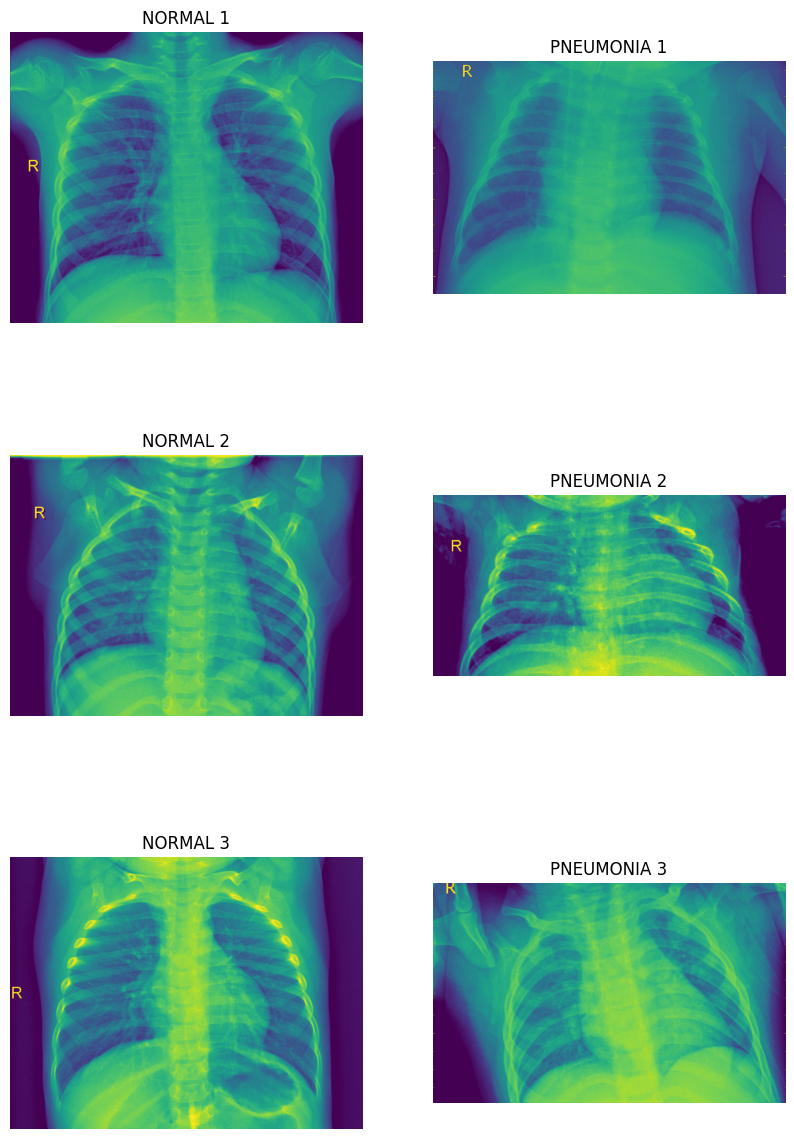

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for i in range(3):
    image_path, label = normal_images[i]
    img = plt.imread(image_path)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{label} {i+1}")
    axes[i, 0].axis('off')

    image_path, label = pneumonia_images[i]
    img = plt.imread(image_path)
    axes[i, 1].imshow(img)
    axes[i, 1].set_title(f"{label} {i+1}")
    axes[i, 1].axis('off') 

plt.show()

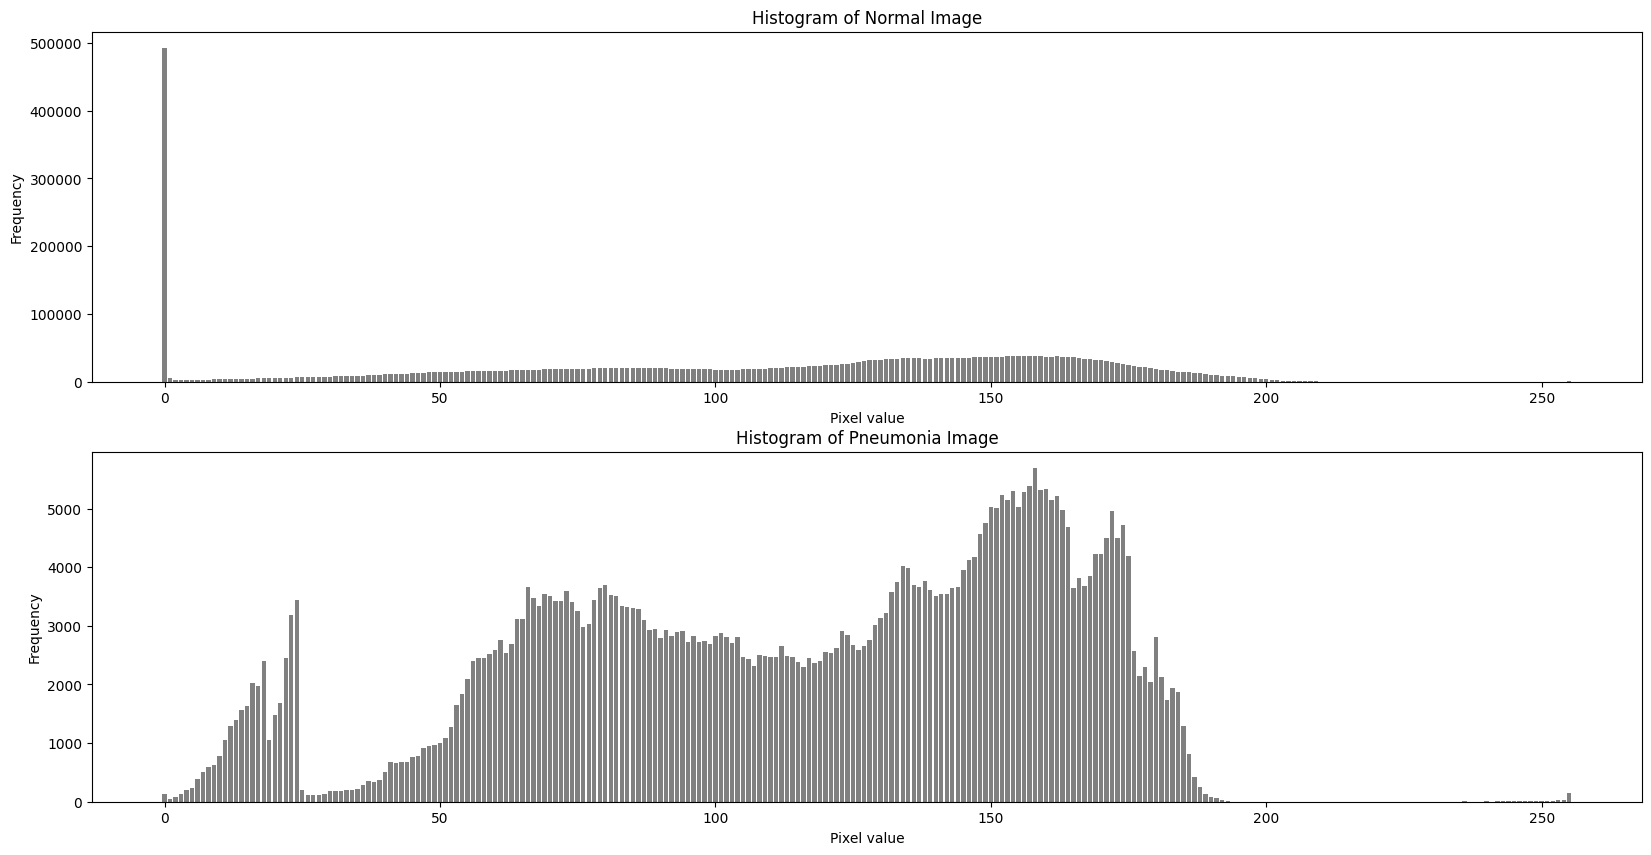

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(20, 10))

img = Image.open(normal_images[0][0])
grayscale_img = img.convert('L')
histogram = grayscale_img.histogram()
axes[0].bar(range(256), histogram, color='gray')
axes[0].set_title('Histogram of Normal Image')
axes[0].set_xlabel('Pixel value')
axes[0].set_ylabel('Frequency')

img = Image.open(pneumonia_images[0][0])
grayscale_img = img.convert('L')
histogram = grayscale_img.histogram()
axes[1].bar(range(256), histogram, color='gray')
axes[1].set_title('Histogram of Pneumonia Image')
axes[1].set_xlabel('Pixel value')
axes[1].set_ylabel('Frequency')

plt.show()

In [8]:
min_width = min_height = float('inf')
max_width = max_height = 0

for root, dirs, files in os.walk(path):
    image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    if '_MACOSX' in root:
        continue
    if not image_files:
        continue

    for image_file in image_files:
        image_path = os.path.join(root, image_file)
        img = Image.open(image_path)
        width, height = img.size

        min_width = min(min_width, width)
        max_width = max(max_width, width)
        min_height = min(min_height, height)
        max_height = max(max_height, height)

print(f"Minimum width: {min_width}")
print(f"Maximum width: {max_width}")
print(f"Minimum height: {min_height}")
print(f"Maximum height: {max_height}")

Minimum width: 384
Maximum width: 2916
Minimum height: 127
Maximum height: 2713


In [9]:
global_size_counter = Counter()

for root, dirs, files in os.walk(path):
    image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    if '_MACOSX' in root:
        continue
    if not image_files:
        continue

    for image_file in image_files:
        image_path = os.path.join(root, image_file)
        img = Image.open(image_path)
        image_size = img.size

        global_size_counter[image_size] += 1

if global_size_counter:
    top_sizes = global_size_counter.most_common(6)
    for size, count in top_sizes:
        print(f"Overall: Size {size} with {count} occurrences")

Overall: Size (1008, 704) with 7 occurrences
Overall: Size (1072, 648) with 7 occurrences
Overall: Size (992, 592) with 6 occurrences
Overall: Size (992, 608) with 6 occurrences
Overall: Size (1216, 872) with 6 occurrences
Overall: Size (1080, 728) with 6 occurrences
